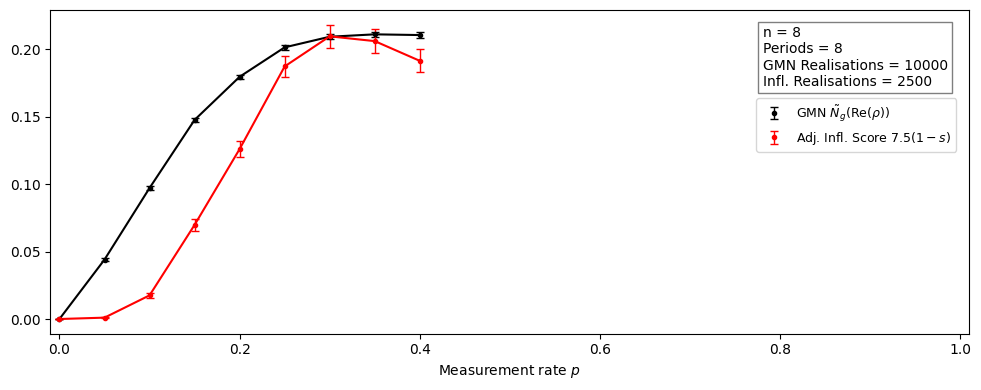

In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# import real GMN data
# df = pd.read_csv('gmn_data_python_arch_real_10k.csv')
# data_array = df.to_numpy().transpose()
# ps = data_array[0]
# gmn_values = data_array[1]

# import complex GMN data
# df4 = pd.read_csv('gmn_archA_complex.csv')
# data_array4 = df4.to_numpy().transpose()
# complex_ps = data_array4[0]
# complex_gmn_values = data_array4[1]

# import GMN/circuit info
df2 = pd.read_csv('info.csv')
data_array2 = df2.to_numpy().transpose()
n = int(data_array2[0][0])
periods = int(data_array2[1][0])
realizations = int(data_array2[2][0])
res = int(data_array2[3][0])
p_min = float(data_array2[4][0])
p_max = float(data_array2[5][0])

# import inflation data
df3 = pd.read_csv('ring_inflation_pyarch_real_2500_0.0_0.35.csv')
data_array3 = df3.to_numpy().transpose()
infl_ps = data_array3[0]
i_gmn_vals = data_array3[1]
infl_scores = data_array3[2]

# get means +/- stds for real GMN
# ps_unique = list(set(ps))
# gmn_means = []
# gmn_stds = []
# for p in ps_unique:
#     gmn_values_for_p = [gmn for gmn, p_val in zip(gmn_values, ps) if p_val == p]
#     gmn_means.append(np.mean(gmn_values_for_p))
#     gmn_stds.append(np.std(gmn_values_for_p, ddof=1)/np.sqrt(realizations*n))
infl_reals = 2500
infl_ps_unique = list(set(infl_ps))
i_gmn_means = []
i_gmn_stds = []
for p in infl_ps_unique:
    infl_values_for_p = [infl for infl, p_val in zip(i_gmn_vals, infl_ps) if p_val == p]
    i_gmn_means.append(np.mean(infl_values_for_p))
    i_gmn_stds.append(np.std(infl_values_for_p, ddof=1)/np.sqrt(infl_reals))

# get means +/- stds for complex GMN
# complex_ps_unique = list(set(complex_ps))
# complex_gmn_means = []
# complex_gmn_stds = []
# for p in complex_ps_unique:
#     complex_gmn_values_for_p = [gmn for gmn, p_val in zip(complex_gmn_values, complex_ps) if p_val == p]
#     complex_gmn_means.append(np.mean(complex_gmn_values_for_p))
#     complex_gmn_stds.append(np.std(complex_gmn_values_for_p, ddof=1)/np.sqrt(realizations*n))

# get means +/- stds for inflation
infl_reals = 2500
infl_ps_unique = list(set(infl_ps))
infl_means = []
infl_stds = []
for p in infl_ps_unique:
    infl_values_for_p = [infl for infl, p_val in zip(infl_scores, infl_ps) if p_val == p]
    infl_means.append(np.mean(infl_values_for_p))
    infl_stds.append(np.std(infl_values_for_p, ddof=1)/np.sqrt(infl_reals))

sorted_pairs = sorted(zip(infl_ps_unique, i_gmn_means))
x_sorted, y_sorted = zip(*sorted_pairs)
# plot GMN
fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))
ax1.errorbar(infl_ps_unique, i_gmn_means, yerr=i_gmn_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1, label=r"GMN $\tilde{N}_g(\text{Re}(\rho))$")
ax1.set_xlabel('Measurement rate $p$')
ax1.plot(x_sorted, y_sorted, color='black')
# ax1.set_ylabel(r'GMN $\tilde{N}_g(\rho)$ = $-\min\;\text{tr}\.(\rho W)$')

# plot complex GMN
# ax1.errorbar(complex_ps_unique, complex_gmn_means, yerr=complex_gmn_stds, fmt='.', color='blue', ecolor='blue', capsize=3, elinewidth=1, label=r"GMN $\tilde{N}_g(\rho)$")


sorted_pairs = sorted(zip(infl_ps_unique, infl_means))
x_sorted, y_sorted = zip(*sorted_pairs)
# plot inflation
scale = 7.5
ax1.errorbar(infl_ps_unique, [scale*(1 - m) for m in infl_means], yerr=scale*np.array(infl_stds), 
             fmt='.', color='red', ecolor='red', capsize=3, elinewidth=1, label=f"Adj. Infl. Score ${scale}(1-s)$")
ax1.plot(x_sorted, [scale*(1-m) for m in y_sorted], color='red')


props = dict(boxstyle='square', facecolor='white', alpha=0.5)
ax1.text(0.775, 0.95, f"n = {n}\nPeriods = {periods}\nGMN Realisations = {realizations}\nInfl. Realisations = {infl_reals}", transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax1.set_xlim(-0.01,1.01)

fig.legend(bbox_to_anchor=(0.9675, 0.675), loc="center right", fontsize=9)
fig.tight_layout()

In [ ]:
from mipt import *
import numpy as np

from mipt_rho3_bin_writer import Rho3BinWriter, ring_subsystem_qubits

n = 8
d = 2 * n
ps = np.linspace(0.0, 1.0, 21)
realisations = 1000

subsystem_qubits = ring_subsystem_qubits(n, closed=True)

with Rho3BinWriter(
    "rho3_python_archA.bin",
    total_qubits=n,
    subsystem_qubits=subsystem_qubits,
    periods=d,
    realizations=realisations,
    p_vals=ps,
) as writer:
    for p_index, p in enumerate(ps):
        print(f"Simulating p = {p}...")
        for r in range(realisations):
            rhos = get_mipt_rho_1d(
                n, d, p,
                subsyst=3,
                all_matrices=True,
                closed=True,
            )

            writer.write_record(
                p_index=p_index,
                realization=r,
                p=float(p),
                rhos=rhos,
            )
            print(f"Realisations: {r}/{realisations}", end='\r', flush=True)
        print()

Simulating p = 0.0...
Realisations: 999/1000
Simulating p = 0.05...
Realisations: 999/1000
Simulating p = 0.1...


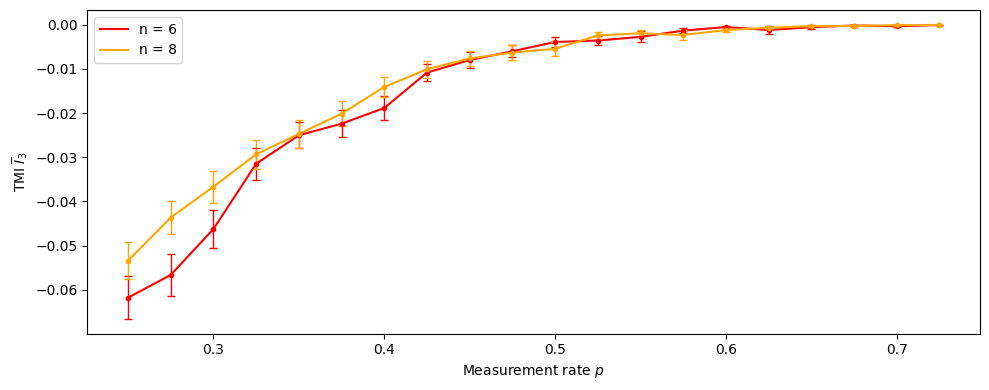

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

realisations = 5000
ns = [8, 12]
ps_arr, mean_arr, std_arr = [], [], []
for n in ns:
    print(f"Importing n = {n}...")
    df = pd.read_csv(f'csv/rho_tmi_python_fermion_n_{n}_real_5000_0.3_0.45.csv')
    data_array = df.to_numpy().transpose()

    ps = data_array[0]
    tmi_vals = data_array[1]
    ps_unique = list(set(ps))
    means = []
    stderrs = []
    for p in ps_unique:
        print(p, " ", end='')
        tmi_for_p = [_tmi for _tmi, p_val in zip(tmi_vals, ps) if p_val == p]
        means.append(np.mean(tmi_for_p))
        stderrs.append(np.std(tmi_for_p, ddof=1)/np.sqrt(realisations))
    print()
    sorted_args = sorted(zip(ps_unique, means, stderrs))
    ps_unique, means, stderrs = zip(*sorted_args)
    ps_arr.append(ps_unique)
    mean_arr.append(means)
    std_arr.append(stderrs)


colors = ["red", "orange", "green", "blue"]

START_INDEX = 10
END_INDEX = 30

fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))
for i in range(len(ns)):
    ax1.errorbar(ps_arr[i][START_INDEX:END_INDEX], mean_arr[i][START_INDEX:END_INDEX], yerr=std_arr[i][START_INDEX:END_INDEX], fmt='.', color=colors[i], ecolor=colors[i], capsize=3, elinewidth=1)
    ax1.plot(ps_arr[i][START_INDEX:END_INDEX], mean_arr[i][START_INDEX:END_INDEX], color=colors[i], label=f"n = {ns[i]}")
ax1.set_xlabel('Measurement rate $p$')
ax1.set_ylabel(r'TMI $\overline{I}_3$')

# props = dict(boxstyle='square', facecolor='white', alpha=0.5)
# ax1.text(0.75, 0.95, f"Realisations = {realisations}", transform=ax1.transAxes, fontsize=10,
#         verticalalignment='top', bbox=props)
 
ax1.legend()
fig.tight_layout()

In [6]:
import numpy as np
print(np.linspace(0.0, 0.1, 21))

[0.    0.005 0.01  0.015 0.02  0.025 0.03  0.035 0.04  0.045 0.05  0.055
 0.06  0.065 0.07  0.075 0.08  0.085 0.09  0.095 0.1  ]


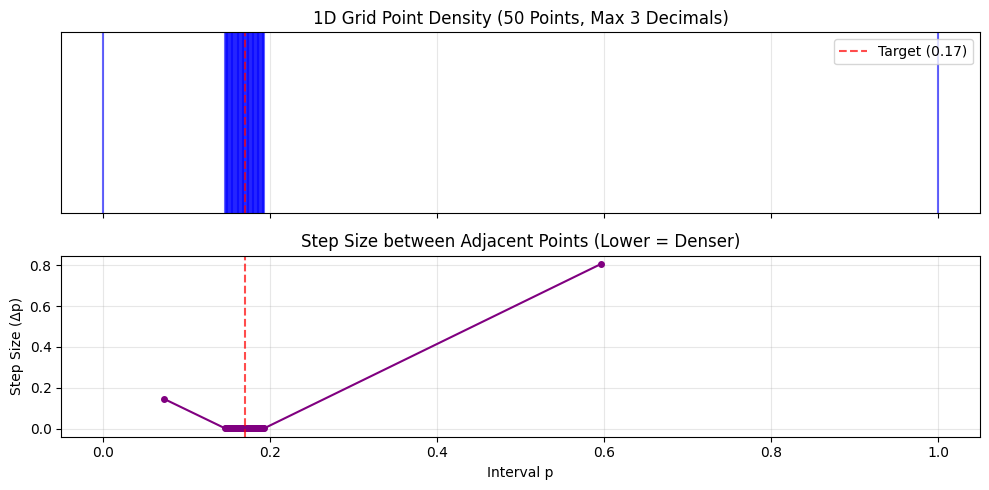

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generate_exact_decimal_grid(target, num_points, precision, spread=0.1):
    """
    Generates an array of exactly 'num_points' between 0.0 and 1.0,
    clustered around 'target', where every point matches the specified 'precision'.
    """
    # 1. Create a master grid of all possible clean decimal steps
    step_size = 10 ** (-precision)
    # Use round to eliminate floating-point arithmetic errors
    master_grid = np.arange(0.0, 1.0 + step_size, step_size)
    master_grid = np.round(master_grid, precision)
    
    # Safety check: If user asks for more points than the precision allows, return the whole grid
    if num_points >= len(master_grid):
        print(f"Warning: Requested {num_points} points, but maximum possible at "
              f"precision {precision} is {len(master_grid)}. Returning full grid.")
        return master_grid

    # 2. Calculate a Gaussian weight for each point based on distance to the target
    # 'spread' controls how wide the high-density cluster is
    weights = np.exp(-0.5 * ((master_grid - target) / spread) ** 2)
    
    # 3. Always force the boundaries (0.0, 1.0) and the closest point to target to be included
    essential_indices = {0, len(master_grid) - 1, np.abs(master_grid - target).argmin()}
    
    # 4. Fill the remaining slots with the highest-weighted points
    remaining_slots = num_points - len(essential_indices)
    
    # Get indices sorted by weight (lowest weight to highest weight)
    sorted_by_weight = np.argsort(weights)
    
    # Filter out the essential indices we already grabbed
    candidates = [idx for idx in sorted_by_weight if idx not in essential_indices]
    
    # Take the top N highest-weighted candidate indices
    chosen_indices = list(essential_indices) + candidates[-remaining_slots:]
    
    # 5. Extract and sort the final grid
    final_grid = master_grid[sorted(chosen_indices)]
    return final_grid

# --- CONFIGURATION ---
TARGET = 0.17       # Where curves meet
NUM_POINTS = 50     # Exact number of points you want in your array
PRECISION = 3       # Bounded decimal places (3 means steps of 0.001, e.g., 0.168)
SPREAD =        # Lower = tighter clustering near 0.17; Higher = more spread out

# Generate the grid
grid = generate_exact_decimal_grid(target=TARGET, num_points=NUM_POINTS, precision=PRECISION, spread=SPREAD)

# --- 1D MATPLOTLIB VISUALIZATION ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

# Subplot 1: Rug Plot
ax1.vlines(grid, 0, 1, colors='blue', alpha=0.6, linewidth=1.5)
ax1.axvline(TARGET, color='red', linestyle='--', alpha=0.7, label=f'Target ({TARGET})')
ax1.set_title(f"1D Grid Point Density ({NUM_POINTS} Points, Max {PRECISION} Decimals)")
ax1.set_yticks([])
ax1.set_ylim(0, 1)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Subplot 2: Step Size (Delta) Chart
deltas = np.diff(grid)
midpoints = grid[:-1] + deltas / 2

ax2.plot(midpoints, deltas, marker='o', color='purple', linestyle='-', markersize=4)
ax2.axvline(TARGET, color='red', linestyle='--', alpha=0.7)
ax2.set_title("Step Size between Adjacent Points (Lower = Denser)")
ax2.set_xlabel("Interval p")
ax2.set_ylabel("Step Size (Δp)")
ax2.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()
